In [2]:
import numpy as np

t_timedata = np.linspace(0, 50,1000)
random_points = np.linspace(0, len(t_timedata)-1, 300).astype(int)
t_data_np = t_timedata[random_points]

print(t_timedata[:5])
print(random_points[:5])
print(t_data_np[:5])

[0.         0.05005005 0.1001001  0.15015015 0.2002002 ]
[ 0  3  6 10 13]
[0.         0.15015015 0.3003003  0.5005005  0.65065065]


In [7]:
colloc_points = np.linspace(0, 1000, 300).astype(int)
print(colloc_points[:5])

[ 0  3  6 10 13]



-----Preparing Vander Pol Data via RK4-----
Collocation points : tensor([[0.0000],
        [0.0501],
        [0.1001],
        [0.1502],
        [0.2002]])
Training data (time): tensor([[0.0000],
        [0.0501],
        [0.1502],
        [0.2002],
        [0.3003]])
Training data (x): tensor([[0.5000],
        [0.4994],
        [0.4944],
        [0.4900],
        [0.4775]])


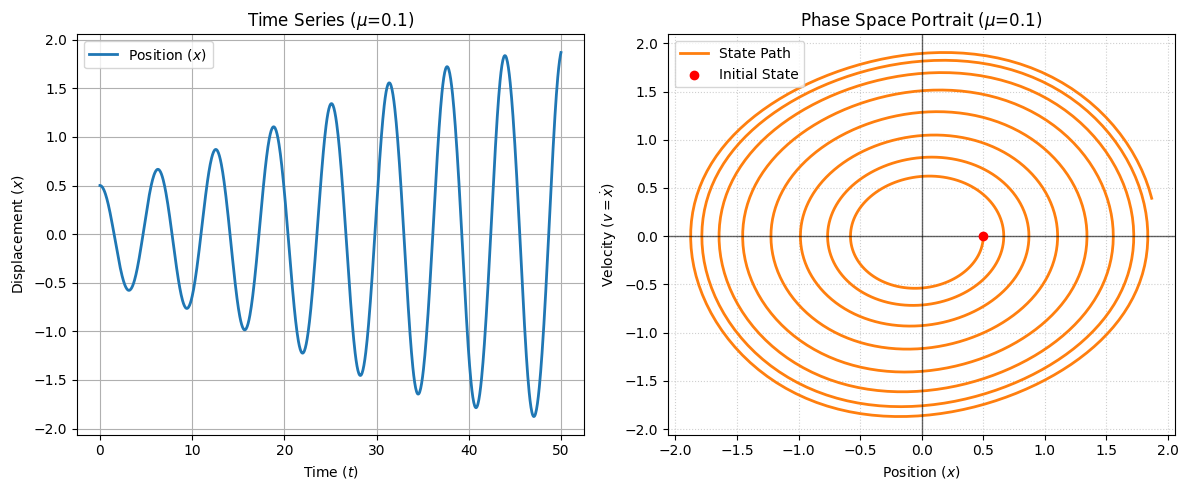

In [1]:
from vdp_func import VDP
from train import train_model, predict_model
from pinn import PINNInverse
import numpy as np
import torch
import matplotlib.pyplot as plt
##-------------------Step 1----------------------------------##
"""
Create observable data
"""
TARGET_MU = 0.1
vanderpol = VDP(mu = TARGET_MU)

t_timedata = np.linspace(0, 50,1000)
initial_condition = [0.5,0.0]
print(f"\n-----Preparing Vander Pol Data via RK4-----")
true_data = vanderpol.generate_trajectory(initial_condition, t_timedata)
plot_data = vanderpol.plot_trajectory(initial_condition, t_timedata)
x_true_positions = true_data[:,0]
v_true_positions = true_data[:,1]


##--------------------- Step 2 --------------------------------##

"""
Feed into PINN
"""
TRAINING_POINTS = 500
COLLOCATION_POINTS = 1000
TRAIN_LENGTH = 40

train_length = t_timedata <= TRAIN_LENGTH
t_train_window = t_timedata[train_length]
x_train_window = x_true_positions[train_length]

random_points = np.linspace(0, len(t_train_window)-1, TRAINING_POINTS).astype(int)
t_data_np = t_timedata[random_points]
x_data_np = x_true_positions[random_points]

t_train_data = torch.tensor(t_data_np, dtype=torch.float32).view(-1,1)
x_train_data = torch.tensor(x_data_np, dtype=torch.float32).view(-1,1)

# Generate 400 uniform grid points for internal physics calculus checking
t_physics = torch.linspace(0, 50, COLLOCATION_POINTS, dtype=torch.float32).view(-1, 1)

print(f"Collocation points : {t_physics[:5]}")
print(f"Training data (time): {t_train_data[:5]}")
print(f"Training data (x): {x_train_data[:5]}")